In [ ]:
with open("../frost_credentials.txt", "r") as file: # Read the client ID from the credentials file
    client_id = file.read().strip()

print("Client ID loaded successfully.") # Display a confirmation message(I wanted to be sure that the client ID was loaded correctly.)

Client ID loaded successfully.


## IMPORTS

In [18]:
import requests
import pandas as pd
import matplotlib.pyplot as plt


## Task 1 – Temperature

### Introduction

The aim of this task is to retrieve and analyse the daily mean air temperature for Ås during 2025 using the Frost API provided by MET Norway.

The weather station used is `SN17850`, and the requested element is the daily mean air temperature. After retrieving the data, the observations will be organised in a pandas DataFrame, visualised in a time-series plot, and summarised using the mean, median, minimum and maximum temperature.


In [12]:

endpoint = "https://frost.met.no/observations/v0.jsonld"

parameters = {
    "sources": "SN17850",
    "elements": "mean(air_temperature P1D)",
    "referencetime": "2025-01-01/2025-12-31",
}

# Send request to Frost API
frost_response = requests.get(
    endpoint,
    parameters,
    auth=(client_id, "")
)

print(frost_response.status_code)  # Display the HTTP status code to check whether the request was successful
'''
The API returned status code `200`, which indicates that the request was successful.
This confirms that the client ID, endpoint, station ID, requested weather variable, and date range were accepted by the Frost API.
'''


200


'\nThe API returned status code `200`, which indicates that the request was successful.\nThis confirms that the client ID, endpoint, station ID, requested weather variable, and date range were accepted by the Frost API.\n'

In [ ]:
# Convert the JSON response to a Python dictionary
frost_data = frost_response.json()

# Check the type and available keys in the response
print(type(frost_data))
print(frost_data.keys())

# Check how many weather records were returned
print("Number of records:", len(frost_data["data"])) # we see that it returned 364 days, so we have to check later which day is missed.)

# Display the first record to inspect its structure
print(frost_data["data"][0]) # we can have an observation of the first record to understand its structure and the fields it contains. This will help us identify which fields we need to extract for our analysis.


<class 'dict'>
dict_keys(['@context', '@type', 'apiVersion', 'license', 'createdAt', 'queryTime', 'currentItemCount', 'itemsPerPage', 'offset', 'totalItemCount', 'currentLink', 'data'])
Number of records: 364
{'sourceId': 'SN17850:0', 'referenceTime': '2025-01-01T00:00:00.000Z', 'observations': [{'elementId': 'mean(air_temperature P1D)', 'value': -5.2, 'unit': 'degC', 'level': {'levelType': 'height_above_ground', 'unit': 'm', 'value': 2}, 'timeOffset': 'PT0H', 'timeResolution': 'P1D', 'timeSeriesId': 0, 'performanceCategory': 'C', 'exposureCategory': '1', 'qualityCode': 0}, {'elementId': 'mean(air_temperature P1D)', 'value': -2.8, 'unit': 'degC', 'level': {'levelType': 'height_above_ground', 'unit': 'm', 'value': 2}, 'timeOffset': 'PT6H', 'timeResolution': 'P1D', 'timeSeriesId': 0, 'performanceCategory': 'C', 'exposureCategory': '1'}]}


In [ ]:
# Extract the date and daily mean temperature from each record (we want to extract only the fields we actually need: date and daily mean temperature.)
temperature_data = [
    {
        "date": pd.to_datetime(entry["referenceTime"]),
        "temperature": entry["observations"][0]["value"],
    }
    for entry in frost_data["data"]
]

# Display the first few extracted records to see we have the correct data
temperature_data[:5]


[{'date': Timestamp('2025-01-01 00:00:00+0000', tz='UTC'),
  'temperature': -5.2},
 {'date': Timestamp('2025-01-02 00:00:00+0000', tz='UTC'),
  'temperature': -11.5},
 {'date': Timestamp('2025-01-03 00:00:00+0000', tz='UTC'),
  'temperature': -8.9},
 {'date': Timestamp('2025-01-04 00:00:00+0000', tz='UTC'),
  'temperature': -15.5},
 {'date': Timestamp('2025-01-05 00:00:00+0000', tz='UTC'),
  'temperature': -12.5}]

In [ ]:
# Convert the extracted temperature records to a pandas DataFrame
temperature_df = pd.DataFrame(temperature_data)

# Sort the data by date
temperature_df = temperature_df.sort_values("date").reset_index(drop=True)

# Display the first 5 rows
print(temperature_df.head())

# Display the number of rows and columns
print("\nDataFrame shape:", temperature_df.shape) #WE see also here that we have 364 rows so for next step we can find the missing day.

                       date  temperature
0 2025-01-01 00:00:00+00:00         -5.2
1 2025-01-02 00:00:00+00:00        -11.5
2 2025-01-03 00:00:00+00:00         -8.9
3 2025-01-04 00:00:00+00:00        -15.5
4 2025-01-05 00:00:00+00:00        -12.5

DataFrame shape: (364, 2)


In [ ]:
# Create a complete daily date range for 2025
all_dates = pd.date_range(
    start="2025-01-01", # We use the start parameter to specify the starting date of the range.
    end="2025-12-31", # We use the end parameter to specify the ending date of the range.
    freq="D", # We use the frequency parameter to specify that we want daily dates.
    tz="UTC" # We use the timezone parameter to specify that we want the dates in UTC timezone.
)

# Find dates that are missing from the dataset
missing_date = all_dates.difference(temperature_df["date"])

print("Missing date:")
print(missing_date) # we can see which day is missing in the data.

Missing dates:
DatetimeIndex(['2025-12-31 00:00:00+00:00'], dtype='datetime64[us, UTC]', freq='D')


In [17]:
# Calculate summary statistics for the 2025 daily mean temperature
temperature_summary = pd.DataFrame({
    "Statistic": ["Mean", "Median", "Minimum", "Maximum"],
    "Temperature (°C)": [
        temperature_df["temperature"].mean(),
        temperature_df["temperature"].median(),
        temperature_df["temperature"].min(),
        temperature_df["temperature"].max(),
    ],
})

# Round the temperature values to two decimal places
temperature_summary["Temperature (°C)"] = (
    temperature_summary["Temperature (°C)"]
)

# Display the summary table
print(temperature_summary.to_string(index=False))

Statistic  Temperature (°C)
     Mean          7.902747
   Median          8.400000
  Minimum        -15.500000
  Maximum         23.700000


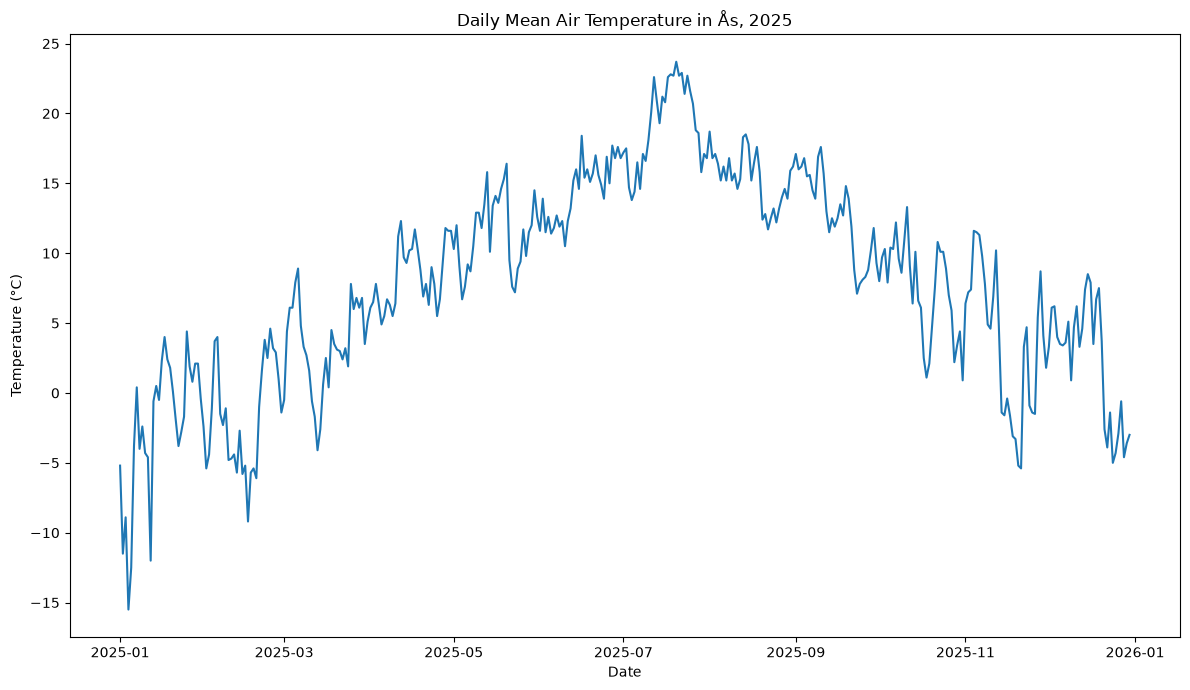

In [23]:
# Plot daily mean temperature for 2025
plt.figure(figsize=(12, 7))

plt.plot(
    temperature_df["date"],
    temperature_df["temperature"]
)

# Add title and axis labels
plt.title("Daily Mean Air Temperature in Ås, 2025")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

# Adjust the layout
plt.tight_layout()

plt.show()



### Results and Discussion

The daily mean air temperature data for Ås in 2025 was successfully retrieved from the Frost API.

The dataset contained 364 daily observations. When comparing the returned dates with the complete 2025 calendar, the observation for 31 December 2025 was missing. No value was manually added for this date, and the analysis was therefore based only on the available observations.

The summary statistics for the available data were:

- Mean temperature: 7.90 °C
- Median temperature: 8.40 °C
- Minimum temperature: -15.50 °C
- Maximum temperature: 23.70 °C

The line plot shows a clear seasonal pattern. Temperatures were lowest during the winter months, increased through spring, reached their highest levels during summer, and then decreased again during autumn and winter.

Overall, the data shows the expected seasonal temperature variation in Ås during 2025.